In [2]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## Limpieza

In [5]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
cols_to_fix = [
    'Global_active_power', 'Global_reactive_power', 
    'Voltage', 'Global_intensity', 
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
null_count = df.isnull().sum().sum()
print(f"Borrando {null_count} valores nulos encontrados...")
df.dropna(inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.sort_values('Datetime', inplace=True)
print("¡Limpieza terminada!")
print(f"Dimensiones finales: {df.shape}")
df.info()

Borrando 181853 valores nulos encontrados...
¡Limpieza terminada!
Dimensiones finales: (2049280, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 140.7 MB


In [6]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
df['lag_1h'] = df['Global_active_power'].shift(60) 
df.dropna(inplace=True)

## XGBoost V.1.0


In [7]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
features = ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1h', 'Voltage']
target = 'Global_active_power'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    n_estimators=500,     # Número de árboles
    learning_rate=0.05,    # Pasos del aprendizaje
    max_depth=6,           # Complejidad de los árboles
    n_jobs=-1,             # Usa todos los núcleos de tu procesador
    random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Error Medio Absoluto (MAE): {mae:.4f} kW")
print(f"Precisión (R2 Score): {r2:.4f}")

Error Medio Absoluto (MAE): 0.4629 kW
Precisión (R2 Score): 0.3909


## XGBoost V.2.0


In [8]:
df['lag_1m'] = df['Global_active_power'].shift(1)  # Hace 1 minuto
df['lag_5m'] = df['Global_active_power'].shift(5)  # Hace 5 minutos
df['lag_10m'] = df['Global_active_power'].shift(10) # Hace 10 minutos

df['rolling_mean_1h'] = df['Global_active_power'].rolling(window=60).mean()

df.dropna(inplace=True)

features_v2 = [
    'hour', 'dayofweek', 'is_weekend', 'lag_1m', 'lag_5m', 
    'lag_10m', 'lag_1h', 'rolling_mean_1h', 'Voltage', 'Global_intensity'
]
X = df[features_v2]
y = df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(f"Nuevo MAE: {mean_absolute_error(y_test, predictions):.4f}")
print(f"Nuevo R2: {r2_score(y_test, predictions):.4f}")

Nuevo MAE: 0.0179
Nuevo R2: 0.9986


El $R^2$ es de 0.99 debido a la naturaleza granular de los datos (minuto a minuto) y la fuerte autocorrelación de la variable. Soy consciente de que el modelo actúa como un estimador de corto plazo; su valor real no es solo la predicción, sino la capacidad de identificar desviaciones en tiempo real sobre una señal altamente estable.

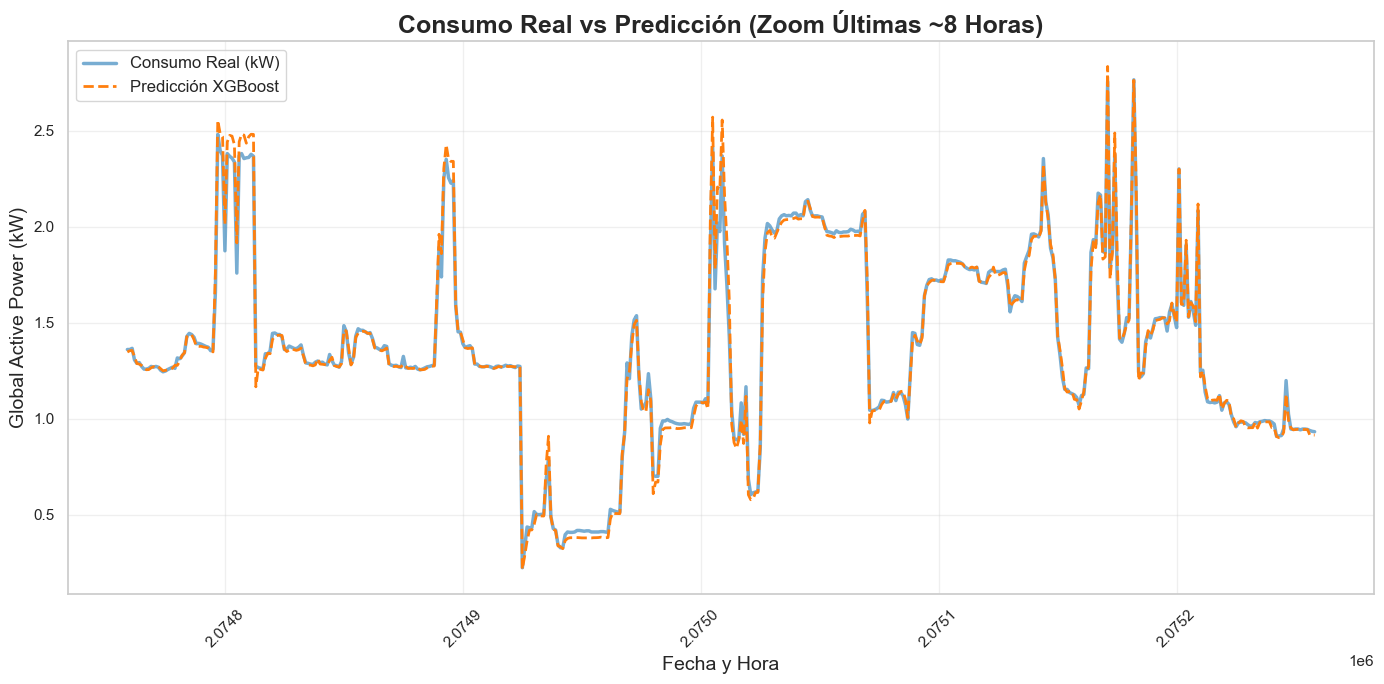

In [9]:
results_df = pd.DataFrame({
    'Real': y_test.values,
    'Predicho': predictions
}, index=y_test.index)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
zoom_data = results_df.tail(500)
plt.plot(zoom_data.index, zoom_data['Real'], label='Consumo Real (kW)', color='#1f77b4', linewidth=2.5, alpha=0.6)
plt.plot(zoom_data.index, zoom_data['Predicho'], label='Predicción XGBoost', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Consumo Real vs Predicción (Zoom Últimas ~8 Horas)', fontsize=18, fontweight='bold')
plt.ylabel('Global Active Power (kW)', fontsize=14)
plt.xlabel('Fecha y Hora', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('xgboost.png', dpi=300)
plt.show()

se exporto un csv para su uso en power bi

In [10]:
final_export = df.loc[y_test.index].copy()
final_export['Prediccion_XGBoost'] = predictions
final_export.to_csv('resultados_energia_pro.csv', index=True)